# Tutorial 3 — K-Means Clustering and PCA
**AIMS Ghana — Machine Learning Course, 2025**

---

## Overview

Two fundamental **unsupervised learning** algorithms:

| Algorithm | Goal |
|---|---|
| **K-Means** | Partition data into $K$ clusters by minimising within-cluster variance |
| **PCA** | Find a low-dimensional projection that preserves maximum variance |

Applications:
- Cluster analysis on synthetic 2D data
- **Image compression** using K-Means colour quantisation
- **Dimensionality reduction** with PCA (sklearn + scratch)


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
plt.style.use('ggplot')


## 2. K-Means from Scratch

### 2.1 Load 2D Data

Data shape: (300, 2)


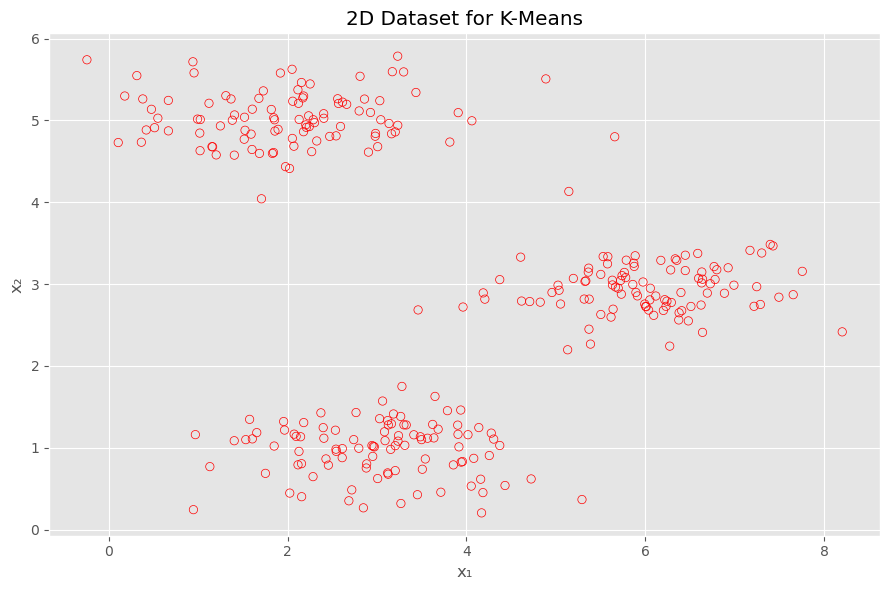

In [4]:
mat  = scipy.io.loadmat('data/kmeans_data.mat')
X    = mat['X']
print(f'Data shape: {X.shape}')

plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], facecolors='none', edgecolors='red')
plt.title('2D Dataset for K-Means')
plt.xlabel('x₁'); plt.ylabel('x₂')
plt.tight_layout(); plt.show()


### 2.2 Step 1 — Find Closest Centroids

Assign each point $x^{(i)}$ to the nearest centroid:
$$c^{(i)} = \arg\min_k \|x^{(i)} - \mu_k\|^2$$


In [5]:
def closest_centroid(X, centroid):
    """
    Assign each training example to the nearest centroid.

    Parameters
    ----------
    X        : training data        (m × n)
    centroid : centroid matrix      (K × n)

    Returns
    -------
    closest_centroid_indices : array of shape (m,) with cluster indices
    """
    K = centroid.shape[0]
    m = X.shape[0]
    closest_centroid_indices = np.zeros(m)
    for i in range(m):
        store_distances = np.zeros(K)
        for j in range(K):
            store_distances[j] = np.sum((X[i, :] - centroid[j, :]) ** 2)
        closest_centroid_indices[i] = np.argmin(store_distances)
    return closest_centroid_indices

initial_centroids = np.array([[3, 3], [6, 2], [8, 5]])

# Test
result = closest_centroid(X, initial_centroids)
print('closest_centroid result (first 5):', result[:5])
print('Unique cluster assignments:', np.unique(result))


closest_centroid result (first 5): [0. 2. 1. 0. 0.]
Unique cluster assignments: [0. 1. 2.]


### 2.3 Step 2 — Compute New Centroids

Recompute each centroid as the mean of its assigned points:
$$\mu_k = \frac{1}{|C_k|}\sum_{i \in C_k} x^{(i)}$$


In [6]:
def compute_centroids(X, indices, k):
    """
    Recompute centroids as the mean of their assigned points.

    Parameters
    ----------
    X       : training examples  (m × n)
    indices : cluster assignment (m,)
    k       : number of clusters

    Returns
    -------
    centroids : (k × n) array
    """
    n         = X.shape[1]
    centroids = np.zeros((k, n))
    for i in range(k):
        points_in_cluster = X[indices == i]
        if len(points_in_cluster) > 0:
            centroids[i, :] = np.mean(points_in_cluster, axis=0)
    return centroids

indx = closest_centroid(X, initial_centroids)
print('New centroids after first step:')
print(compute_centroids(X, indx, 3))


New centroids after first step:
[[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


### 2.4 Full K-Means Loop

> ⚠️ **Bug fixed:** The original `runkMeans` used `initial_centroids.shape[0]` (a global variable) instead of `initial_centroid.shape[0]` (the function parameter). This caused silent errors when calling the function with different centroids.


In [7]:
def runkMeans(X, initial_centroid, nbr_iters):
    """
    Run K-Means for a fixed number of iterations.

    Parameters
    ----------
    X               : training data        (m × n)
    initial_centroid: starting centroids   (K × n)
    nbr_iters       : number of iterations

    Returns
    -------
    (centroids, indx)

    FIX: uses initial_centroid.shape[0] (parameter), NOT initial_centroids (global).
    """
    nbr_of_train_data  = X.shape[0]
    nbr_of_centroids   = initial_centroid.shape[0]    # FIX: was initial_centroids (global)
    centroids          = initial_centroid.copy()
    indx               = np.zeros(nbr_of_train_data)

    for i in range(nbr_iters):
        indx      = closest_centroid(X, centroids)
        centroids = compute_centroids(X, indx, nbr_of_centroids)

    return (centroids, indx)

centroids, idx = runkMeans(X, initial_centroids, 10)
print('Final centroids:')
for k, c in enumerate(centroids):
    print(f'  Cluster {k}: {c}  — {(idx==k).sum()} points')


Final centroids:
  Cluster 0: [1.95399466 5.02557006]  — 98 points
  Cluster 1: [3.04367119 1.01541041]  — 102 points
  Cluster 2: [6.03366736 3.00052511]  — 100 points


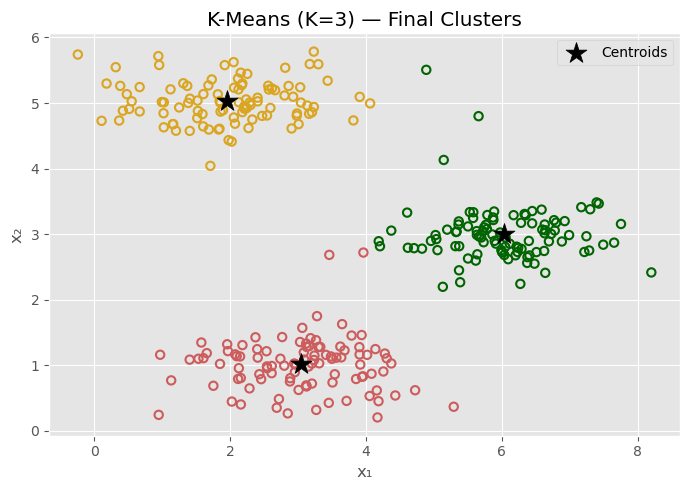

In [8]:
# Colour map for clusters
def clusterColors(idx, k):
    """Return a list of random CSS colours, one per data point."""
    colors     = mcolors.CSS4_COLORS.keys()
    rand_colors = np.random.choice(list(colors), size=k)
    colors_map  = {i: rand_colors[i] for i in range(k)}
    return [colors_map[int(i)] for i in idx]

colors = clusterColors(idx, 3)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], facecolors='none', edgecolors=colors, linewidths=1.5)
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='*', s=250, color='black', zorder=5, label='Centroids')
plt.title('K-Means (K=3) — Final Clusters')
plt.xlabel('x₁'); plt.ylabel('x₂'); plt.legend()
plt.tight_layout(); plt.show()


### 2.5 K-Means for Image Compression

Each pixel $x_i \in \mathbb{R}^3$ (RGB) is replaced by its cluster centroid.
With $K=16$ we store only 16 colours instead of millions.

$$x_i \mapsto c_{c^{(i)}}$$


Image shape: (128, 128, 3)  |  dtype: float32


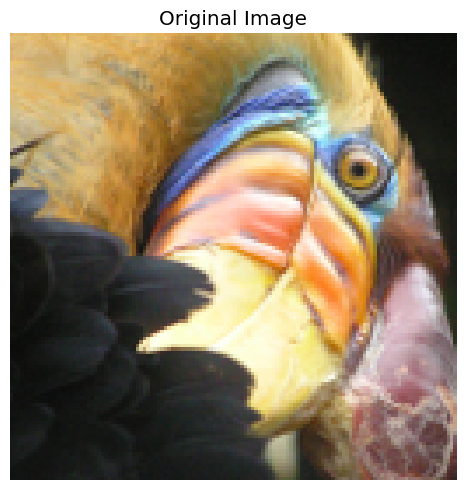

In [10]:
# Load image
A = plt.imread('images/bird_small.png')
print(f'Image shape: {A.shape}  |  dtype: {A.dtype}')

plt.figure(figsize=(5, 5))
plt.imshow(A); plt.axis('off')
plt.title('Original Image'); plt.tight_layout(); plt.show()


In [11]:
# Reshape image to list of pixels (m, 3)
X_img = np.reshape(A, (A.size // A.shape[2], A.shape[2]))
print(f'Pixel matrix shape: {X_img.shape}')

k = 16
np.random.seed(42)
initial_centroids_img = X_img[np.random.randint(0, X_img.shape[0], k)]

centroids_img, idx_img = runkMeans(X_img, initial_centroids_img, 10)
print(f'K-Means converged with {k} colour clusters.')


Pixel matrix shape: (16384, 3)
K-Means converged with 16 colour clusters.


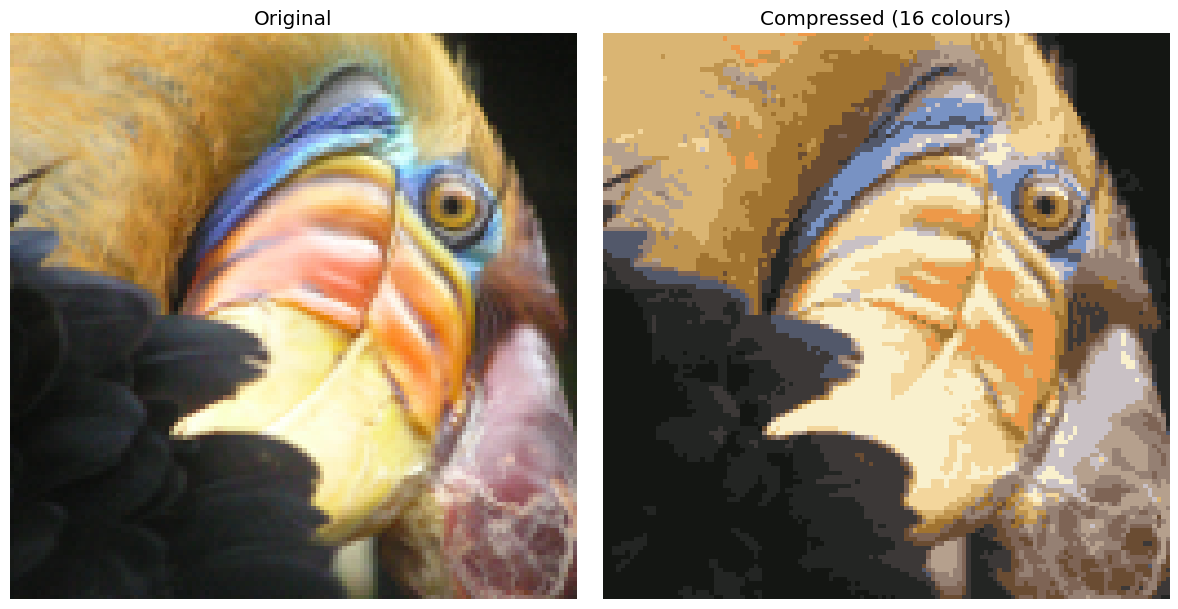

In [12]:
def reconstruct_from_kmeans(centroids, indices):
    """Reconstruct the image by replacing each pixel with its centroid colour."""
    return np.array([centroids[int(i)] for i in indices]).reshape(A.shape)

X_recovered = reconstruct_from_kmeans(centroids_img, idx_img)

fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(A);                        plt.axis('off'); plt.title('Original')
plt.subplot(1, 2, 2); plt.imshow(np.clip(X_recovered,0,1)); plt.axis('off'); plt.title(f'Compressed ({k} colours)')
fig.tight_layout(); plt.show()


## 3. PCA

### 3.1 Using scikit-learn

PCA finds the **directions of maximum variance** and projects data onto them.


Explained variance ratio: [0.61090466 0.38909534]
PC1: 61.1%  |  PC2: 38.9%


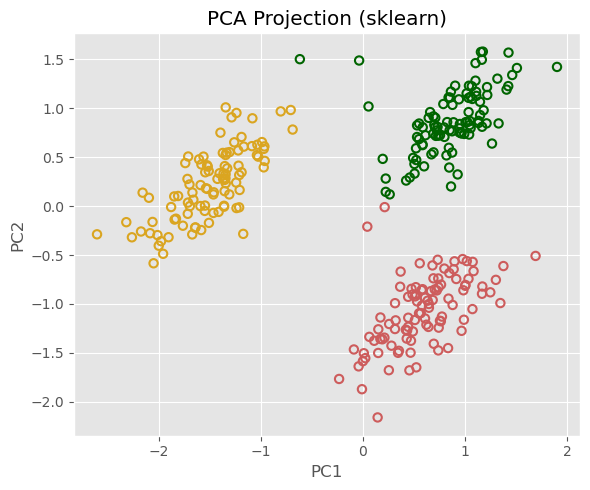

In [13]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

n = 2
pca    = PCA(n_components=n)
X_proj = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  |  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')

plt.figure(figsize=(6, 5))
plt.scatter(X_proj[:, 0], X_proj[:, 1],
            facecolors='none', edgecolors=colors, linewidths=1.5)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA Projection (sklearn)')
plt.tight_layout(); plt.show()


Reconstructed shape: (300, 2)


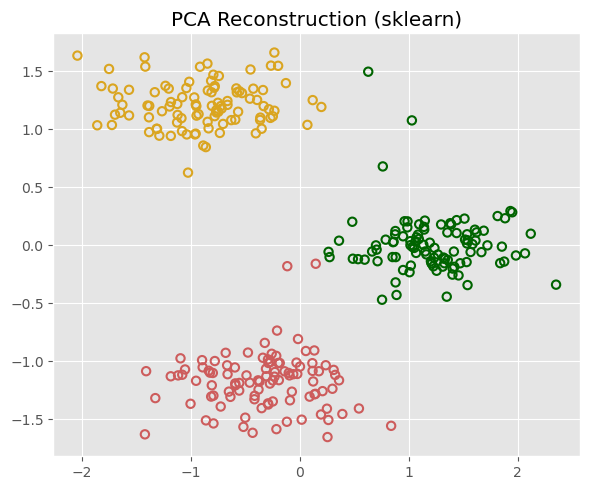

In [14]:
# Reconstruct from 2 components
X_reconstructed = pca.inverse_transform(X_proj)
print('Reconstructed shape:', X_reconstructed.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1],
            facecolors='none', edgecolors=colors, linewidths=1.5)
plt.title('PCA Reconstruction (sklearn)')
plt.tight_layout(); plt.show()


### 3.2 PCA from Scratch

> ⚠️ **Bug fixed:** The original code had:
> ```python
> X_meaned = X - np.mean(X, axis=0) / np.std(X, axis=0)
> ```
> Due to operator precedence, the division applied **only to the mean**, not to `X - mean`.
> The correct standardisation is:
> ```python
> X_meaned = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
> ```


In [15]:
def pca_from_scratch(X, n):
    """
    PCA from scratch.

    Steps:
      1. Standardise: (X - mean) / std
      2. Compute covariance matrix
      3. Eigendecompose
      4. Sort eigenvectors by decreasing eigenvalue
      5. Project onto top n eigenvectors

    FIX: correct standardisation formula — parentheses around (X - mean).

    Parameters
    ----------
    X : data matrix (m × d)
    n : number of principal components

    Returns
    -------
    X_reduced         : projected data  (m × n)
    eigenvector_subset: top-n eigenvectors (d × n)
    X_mean            : per-feature mean (d,)
    """
    # 1. Standardise  — FIX: was X - mean/std, should be (X-mean)/std
    X_meaned = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

    # 2. Covariance matrix
    cov_mat = np.cov(X_meaned, rowvar=False)

    # 3. Eigendecomposition
    eigen_values, eigen_vectors = np.linalg.eigh(cov_mat)

    # 4. Sort descending
    sorted_index      = np.argsort(eigen_values)[::-1]
    sorted_eigenvalue = eigen_values[sorted_index]
    sorted_eigenvectors = eigen_vectors[:, sorted_index]

    # 5. Select top-n and project
    eigenvector_subset = sorted_eigenvectors[:, :n]
    X_reduced = (eigenvector_subset.T @ X_meaned.T).T

    return X_reduced, eigenvector_subset, np.mean(X, axis=0)

X_proj_scratch, eigenvector_subset, X_mean = pca_from_scratch(X_scaled, 4)
print('Projected shape:', X_proj_scratch.shape)


Projected shape: (300, 2)


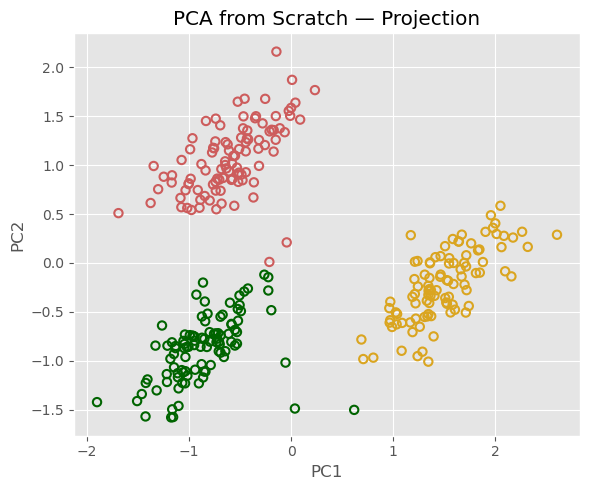

In [16]:
plt.figure(figsize=(6, 5))
plt.scatter(X_proj_scratch[:, 0], X_proj_scratch[:, 1],
            facecolors='none', edgecolors=colors, linewidths=1.5)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA from Scratch — Projection')
plt.tight_layout(); plt.show()


Reconstruction shape: (300, 2)


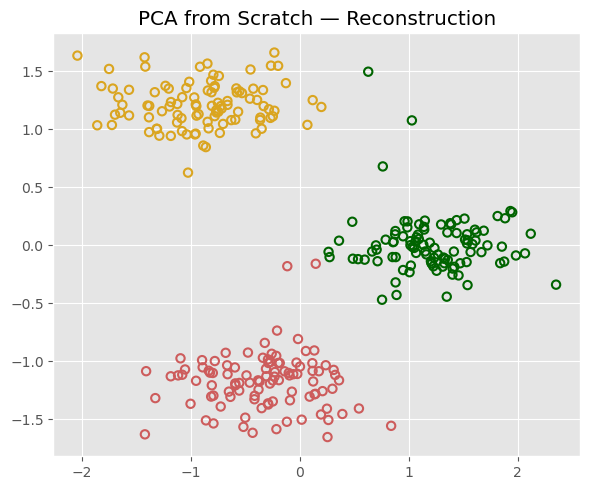

In [17]:
def reconstruct_from_pca(X_reduced, eigenvectors, X_mean):
    """Reconstruct original-space data from PCA projection."""
    return X_reduced @ eigenvectors.T + X_mean

X_pca_reconstructed = reconstruct_from_pca(X_proj_scratch, eigenvector_subset, X_mean)
print('Reconstruction shape:', X_pca_reconstructed.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca_reconstructed[:, 0], X_pca_reconstructed[:, 1],
            facecolors='none', edgecolors=colors, linewidths=1.5)
plt.title('PCA from Scratch — Reconstruction')
plt.tight_layout(); plt.show()


**Note:** The sign of principal components may differ between sklearn and the scratch implementation — this is expected and does not affect quality.

### When to use PCA
- Visualise high-dimensional data in 2D / 3D
- Remove noise (discard low-variance components)
- Speed up downstream ML models
- Image compression

> PCA finds **linear** projections. For non-linear structure, consider t-SNE or UMAP.
